In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> src/pipelines/04_eda_annot_gt_cycle/05_fnd_button_press_eda.py.
> Edit the source and re-export; do not edit the exported notebook by hand.

# Button-press ground truth: inventory + press-vs-activation alignment

The UK-DALE deployment asked occupants to press a wireless button when
they used an appliance - the closest thing the corpus has to a human
annotation stream, and the empirical basis for the button-press
calibration simulation (H02). The FND staging ships those presses as
event parquets (data/fnd/ukdale/house_N/channel_M_button_press.parquet,
columns ts_us + v0). Three questions, all answered visually first:

1. **Inventory** - which channels have presses, how many, over what era?
2. **Semantics** - are the events press/release pairs (v0 in {0, 1})?
3. **Alignment** - does a press predict a submeter activation? At what
   latency? What share of activations carries no press at all?

Alignment windows and eligibility floors are notebook parameters, not
gates; all numbers provisional.

In [ ]:
# Headless rendering + shared baseline lib (same pattern as 01/03/04).
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
_here = Path(__file__).resolve()
import json
import sys as _sys

_sys.path.insert(0, str(_here.parents[2] / "experiments" / "00_baseline"))
import baseline_lib as bl
ROOT = Path(bl.ROOT)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# --- Notebook parameters (provisional, stated up front) ---------------
cfg = {
    "dataset": "ukdale",
    "houses": ("house_1", "house_2", "house_3", "house_4", "house_5"),
    "align_win_s": 1800.0,  # press -> next activation match window
    "act_press_s": 60.0,  # grace after activation start for a press to count
    "min_presses": 8,  # minimum presses for alignment stats
    "exemplars": (
        ("house_1", 24, "bedroom_ds_lamp"),
        ("house_1", 33, "utilityrm_lamp"),
        ("house_1", 22, "hoover"),
        ("house_1", 10, "kettle"),
    ),
}

In [ ]:
mo.md(
    "## Parameters used in this EDA\n\n"
    + bl.md_table(
        ["parameter", "value"],
        [[k, v] for k, v in cfg.items()],
    )
)

## Parameters used in this EDA

| parameter | value |
|---|---|
| dataset | ukdale |
| houses | ('house_1', 'house_2', 'house_3', 'house_4', 'house_5') |
| align_win_s | 1800.0 |
| act_press_s | 60.0 |
| min_presses | 8 |
| exemplars | (('house_1', 24, 'bedroom_ds_lamp'), ('house_1', 33, 'utilityrm_lamp'), ('house_1', 22, 'hoover'), ('house_1', 10, 'kettle')) |

In [ ]:
# --- Button-press inventory (computation) -------------------------------
_btn = ROOT / "data" / "fnd" / "ukdale"
_amap = json.loads(
    (ROOT / "data" / "gold" / "appliance_map_ukdale.json").read_text()
)["ukdale"]
_rows = []
for _p in sorted(_btn.glob("house_*/channel_*_button_press.parquet")):
    _house = _p.parent.name
    _ch = int(_p.name.split("_")[1])
    _df = pd.read_parquet(_p)
    _lab = (
        _amap.get(_house, {})
        .get("channels", {})
        .get(str(_ch), {})
        .get("label", f"ch{_ch}")
    )
    _ts = _df["ts_us"].to_numpy()
    _v = _df["v0"].to_numpy()
    _rows.append(
        {
            "house": _house,
            "ch": _ch,
            "label": _lab,
            "events": len(_df),
            "presses": int((_v == 1).sum()),
            "releases": int((_v == 0).sum()),
            "span_d": (_ts.max() - _ts.min()) / 86_400_000_000,
            "t_min": pd.to_datetime(_ts.min(), unit="us").strftime("%Y-%m-%d"),
            "t_max": pd.to_datetime(_ts.max(), unit="us").strftime("%Y-%m-%d"),
        }
    )
inv_df = pd.DataFrame(_rows)
# pooled press-hour histograms per house (diurnal figure)
_hours = {}
for _house in sorted(inv_df["house"].unique()):
    _hs = []
    for _p in sorted(_btn.glob(f"{_house}/channel_*_button_press.parquet")):
        _df = pd.read_parquet(_p)
        _hs.append(
            (_df.loc[_df["v0"] == 1, "ts_us"].to_numpy() // 3_600_000_000) % 24
        )
    _hours[_house] = np.concatenate(_hs) if _hs else np.array([])
press_hours = _hours

In [ ]:
# presentation: inventory summary + full channel table
_agg = (
    inv_df.groupby("house")
    .agg(files=("ch", "count"), presses=("presses", "sum"), releases=("releases", "sum"))
    .reindex(["house_1", "house_2", "house_3", "house_4", "house_5"], fill_value=0)
    .reset_index()
)
_agg_rows = [[_r["house"], str(_r["files"]), f"{_r['presses']:,}", f"{_r['releases']:,}"] for _r in _agg.to_dict("records")]
_top = inv_df.sort_values("presses", ascending=False).head(20)
_top_rows = [
    [
        _r["house"].replace("house_", "h"),
        f"ch{_r['ch']}",
        _r["label"],
        f"{_r['presses']:,}",
        f"{_r['releases']:,}",
        f"{_r['span_d']:.0f}",
        _r["t_min"],
        _r["t_max"],
    ]
    for _r in _top.to_dict("records")
]
mo.md(
    "## 1. Inventory\n\n"
    f"{len(inv_df)} button-press files across the corpus (UK-DALE only - "
    "the FND staging has no button channels for house_3/house_4):\n\n"
    + bl.md_table(["house", "files", "presses (v0=1)", "releases (v0=0)"], _agg_rows)
    + "\n\nTop 20 channels by press count. Spans cover essentially the "
    "whole deployment era (median span ~4 years), so presses are "
    "time-aligned with the submeter data. h2/h5 logs are one to two "
    "orders of magnitude sparser than h1:\n\n"
    + bl.md_table(
        ["house", "ch", "label", "presses", "releases", "span (d)", "first", "last"],
        _top_rows,
    )
    + "\n\n**Encoding.** v0 is binary: 1 = press, 0 = release. Presses "
    "exceed releases on every channel (h1: 8,550 vs 7,328) - the surplus "
    "is held buttons and presses near the log boundary. Release events "
    "carry no appliance semantics we would trust; everything below uses "
    "presses only."
)

## 1. Inventory

71 button-press files across the corpus (UK-DALE only - the FND staging has no button channels for house_3/house_4):

| house | files | presses (v0=1) | releases (v0=0) |
|---|---|---|---|
| house_1 | 48 | 8,550 | 7,328 |
| house_2 | 11 | 42 | 38 |
| house_3 | 0 | 0 | 0 |
| house_4 | 0 | 0 | 0 |
| house_5 | 12 | 121 | 120 |

Top 20 channels by press count. Spans cover essentially the whole deployment era (median span ~4 years), so presses are time-aligned with the submeter data. h2/h5 logs are one to two orders of magnitude sparser than h1:

| house | ch | label | presses | releases | span (d) | first | last |
|---|---|---|---|---|---|---|---|
| h1 | ch34 | samsung_charger | 1,160 | 991 | 1497 | 2013-03-21 | 2017-04-25 |
| h1 | ch29 | livingroom_lamp_tv | 896 | 751 | 1497 | 2013-03-21 | 2017-04-26 |
| h1 | ch26 | livingroom_s_lamp2 | 761 | 625 | 1492 | 2013-03-20 | 2017-04-20 |
| h1 | ch24 | bedroom_ds_lamp | 699 | 619 | 1495 | 2013-03-23 | 2017-04-25 |
| h1 | ch45 | childs_ds_lamp | 628 | 541 | 1437 | 2013-03-20 | 2017-02-24 |
| h1 | ch19 | livingroom_s_lamp | 613 | 505 | 1376 | 2013-03-21 | 2016-12-26 |
| h1 | ch49 | office_lamp2 | 506 | 462 | 1419 | 2013-04-11 | 2017-02-28 |
| h1 | ch33 | utilityrm_lamp | 479 | 445 | 1429 | 2013-05-22 | 2017-04-20 |
| h1 | ch43 | data_logger_pc | 394 | 383 | 1452 | 2013-03-20 | 2017-03-11 |
| h1 | ch48 | office_lamp1 | 313 | 279 | 1438 | 2013-04-11 | 2017-03-19 |
| h1 | ch12 | fridge | 173 | 162 | 1460 | 2013-03-20 | 2017-03-19 |
| h1 | ch15 | hifi_office | 156 | 148 | 1478 | 2013-03-20 | 2017-04-06 |
| h1 | ch10 | kettle | 130 | 98 | 1486 | 2013-03-20 | 2017-04-14 |
| h1 | ch32 | kitchen_phone&stereo | 111 | 98 | 1435 | 2013-03-20 | 2017-02-22 |
| h1 | ch36 | coffee_machine | 101 | 96 | 1414 | 2013-03-20 | 2017-02-01 |
| h1 | ch13 | microwave | 100 | 91 | 1493 | 2013-03-20 | 2017-04-21 |
| h1 | ch5 | washing_machine | 92 | 85 | 1270 | 2013-03-20 | 2016-09-10 |
| h5 | ch9 | core2_server | 83 | 83 | 65 | 2014-09-08 | 2014-11-12 |
| h1 | ch22 | hoover | 83 | 66 | 1493 | 2013-03-25 | 2017-04-26 |
| h1 | ch52 | office_fan | 79 | 57 | 1185 | 2013-06-19 | 2016-09-16 |

**Encoding.** v0 is binary: 1 = press, 0 = release. Presses exceed releases on every channel (h1: 8,550 vs 7,328) - the surplus is held buttons and presses near the log boundary. Release events carry no appliance semantics we would trust; everything below uses presses only.

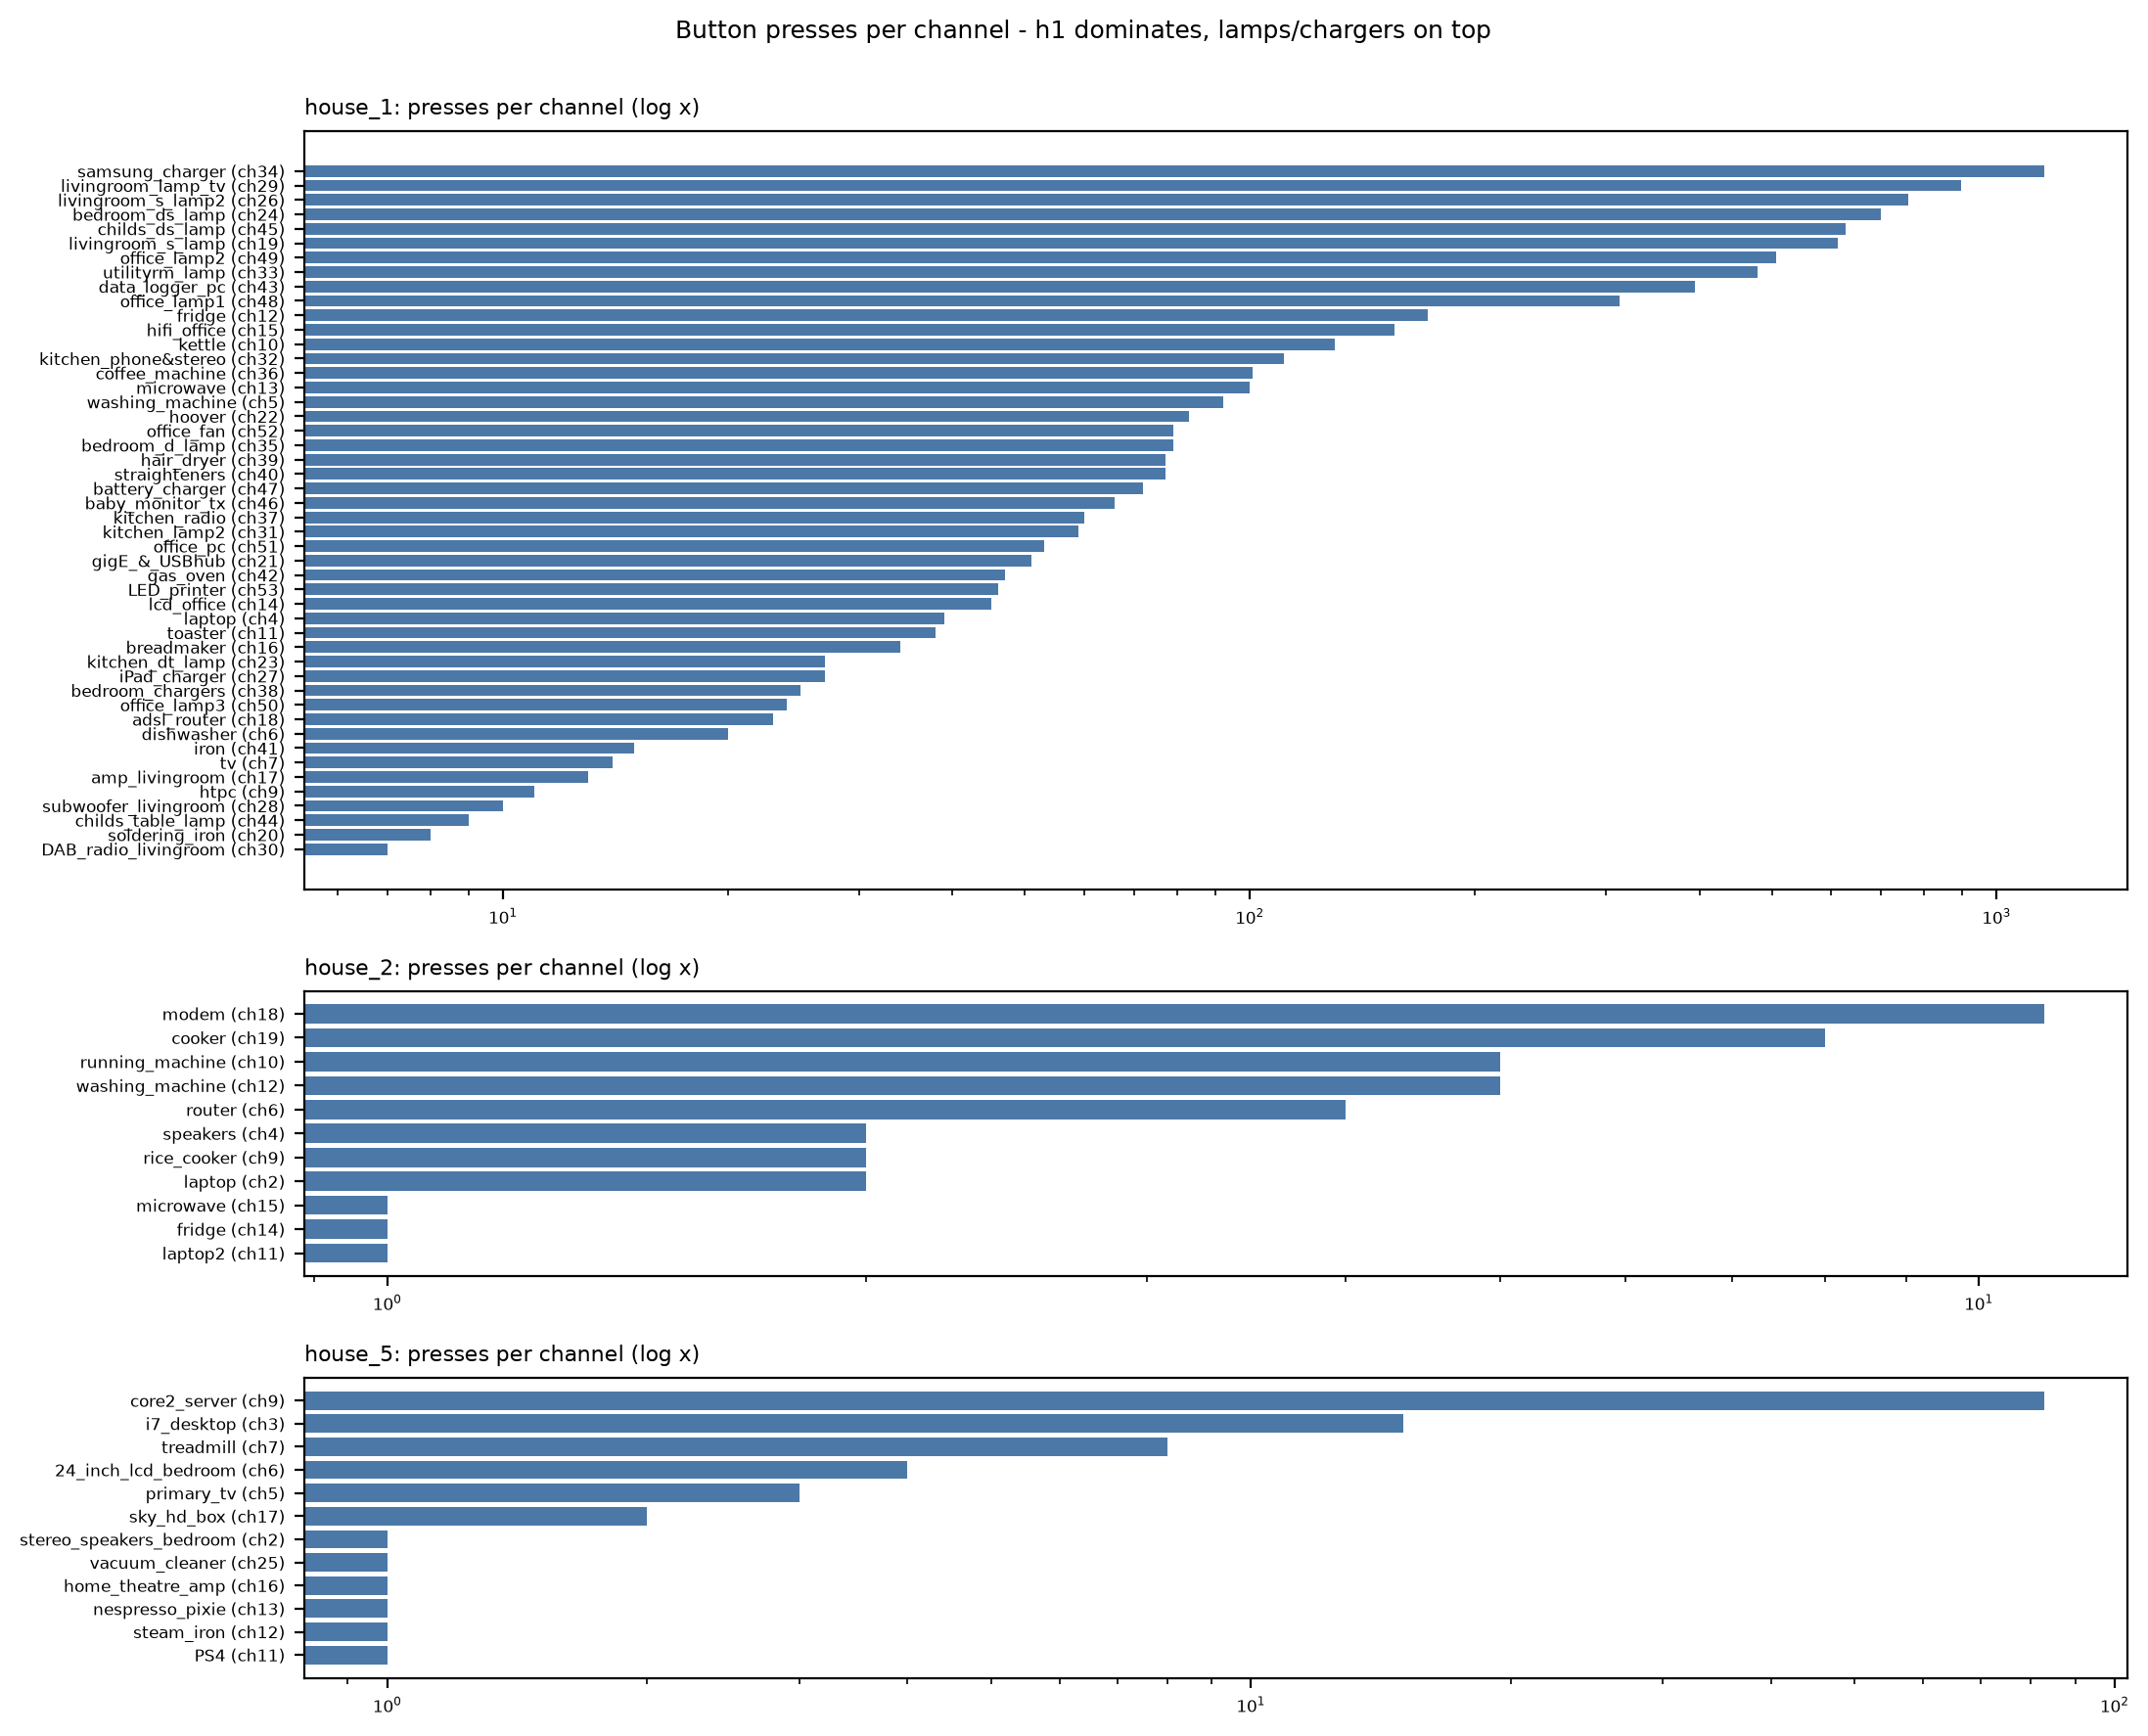

In [ ]:
# --- Figure: presses per channel per house -------------------------------
fig_press_rank, _axes = plt.subplots(
    3,
    1,
    figsize=(11, 9.0),
    gridspec_kw={"height_ratios": [2.4, 0.9, 0.95]},
)
for _ax, _house in zip(_axes, ("house_1", "house_2", "house_5")):
    _sub = inv_df[inv_df["house"] == _house].sort_values("presses", ascending=True)
    _ax.barh(
        [f"{_r['label']} (ch{_r['ch']})" for _r in _sub.to_dict("records")],
        _sub["presses"].to_numpy(),
        color="#4c78a8",
    )
    _ax.set_xscale("log")
    _ax.tick_params(labelsize=6)
    _ax.set_title(f"{_house}: presses per channel (log x)", fontsize=8, loc="left")
fig_press_rank.suptitle("Button presses per channel - h1 dominates, lamps/chargers on top", fontsize=9)
fig_press_rank.tight_layout(rect=(0, 0, 1, 0.985))
fig_press_rank  # noqa: B018  (render figure as cell output)

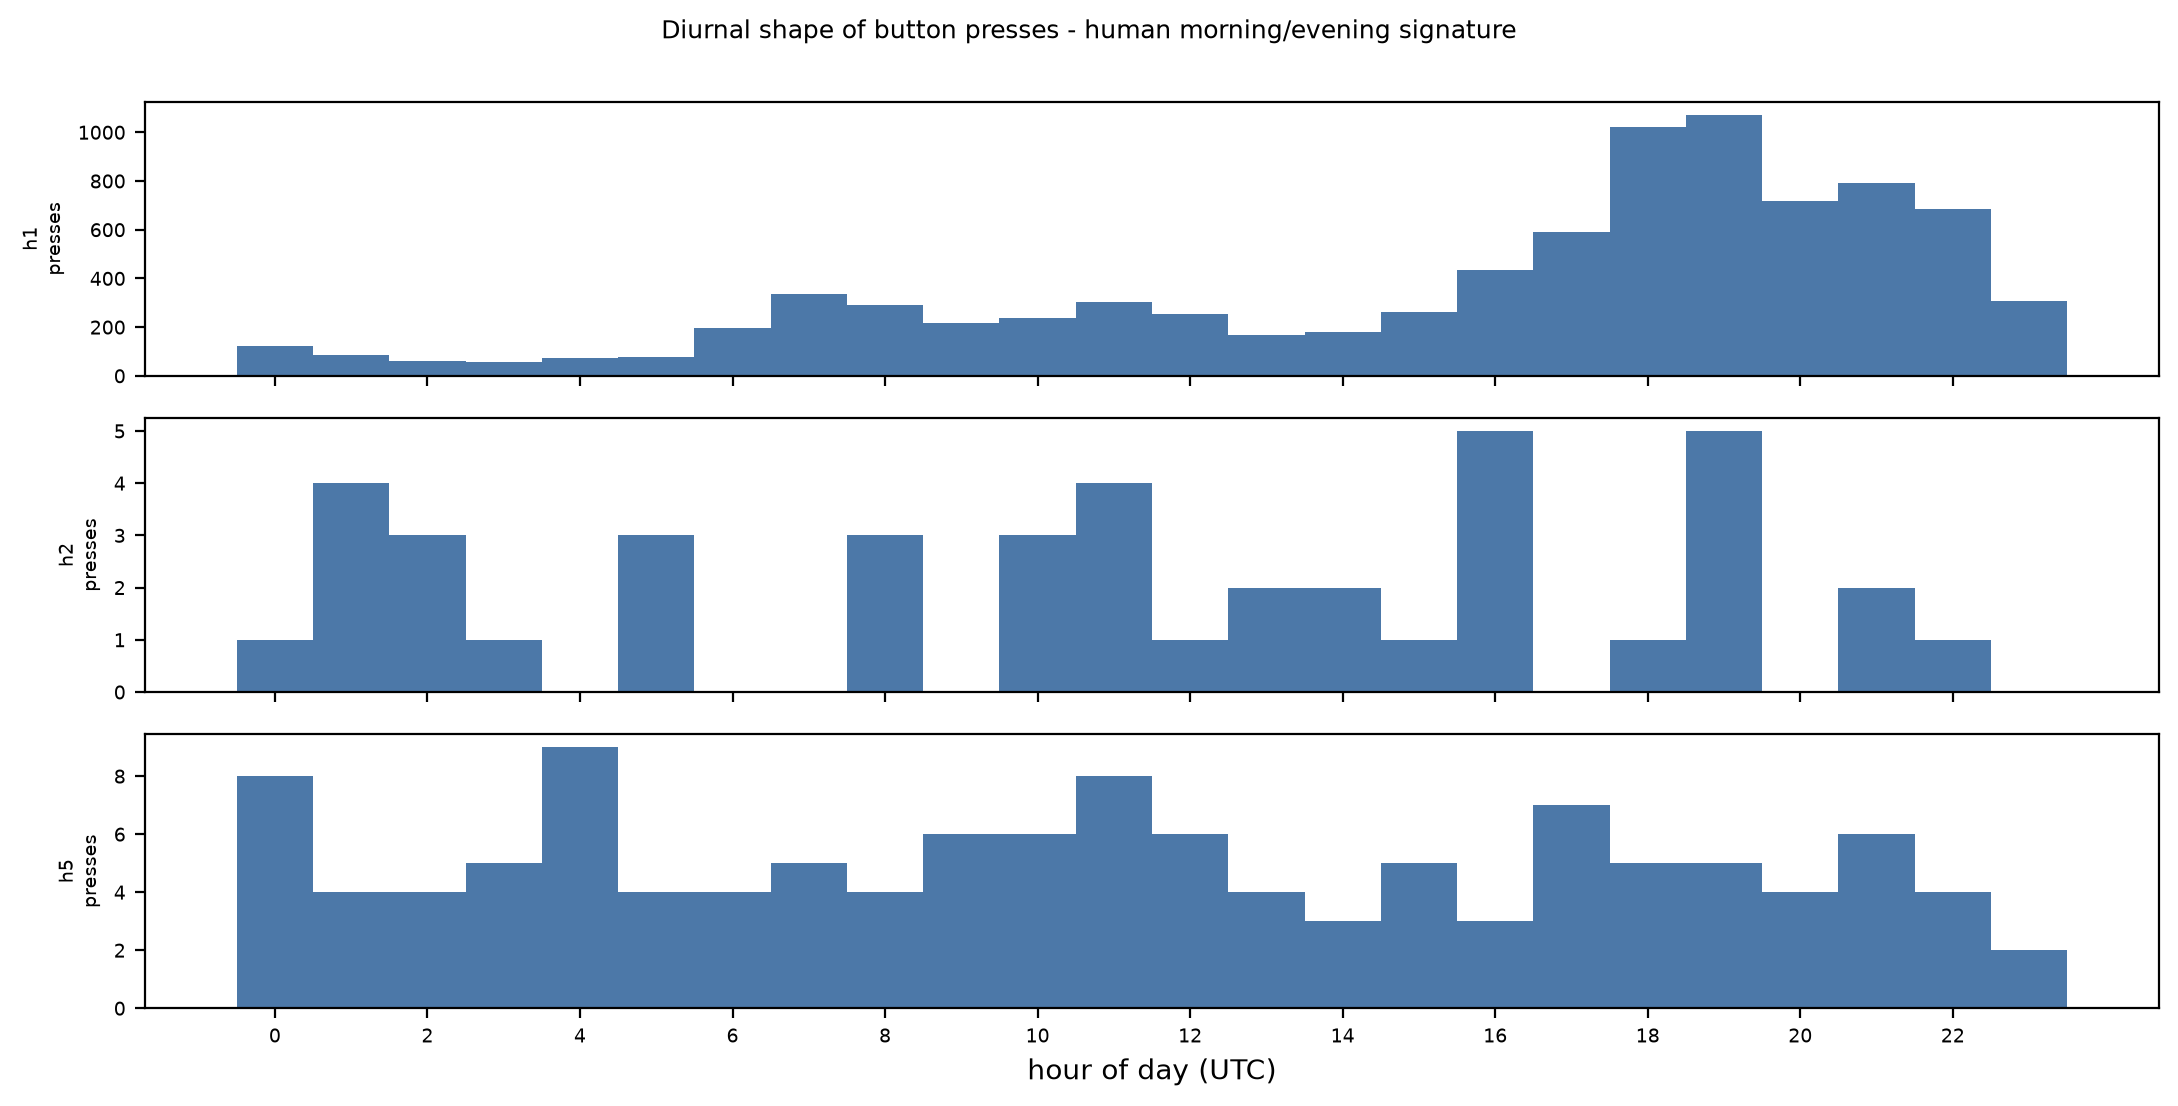

In [ ]:
# --- Figure: diurnal shape of presses ------------------------------------
fig_diurnal, _axes = plt.subplots(3, 1, figsize=(11, 5.6), sharex=True)
for _ax, _house in zip(_axes, ("house_1", "house_2", "house_5")):
    _h = press_hours.get(_house, np.array([]))
    _bins = np.arange(25) - 0.5
    _ax.hist(_h, bins=_bins, color="#4c78a8")
    _ax.set_ylabel(f"{_house.replace('house_', 'h')}\npresses", fontsize=7)
    _ax.tick_params(labelsize=7)
_axes[-1].set_xlabel("hour of day (UTC)")
_axes[-1].set_xticks(range(0, 24, 2))
fig_diurnal.suptitle("Diurnal shape of button presses - human morning/evening signature", fontsize=9)
fig_diurnal.tight_layout(rect=(0, 0, 1, 0.985))
fig_diurnal  # noqa: B018  (render figure as cell output)

In [ ]:
# --- Loaders + alignment helpers (computation) ---------------------------
_cache = {}

def load_chan(house, name):
    key = (house, name)
    if key not in _cache:
        _cache[key] = bl.load_series(bl.gold_file(cfg["dataset"], house, name))
    return _cache[key]

_prof_cache = {}

def profile_of(house):
    if house not in _prof_cache:
        _prof_cache[house] = pd.read_csv(
            ROOT / "data" / "gold_annot" / cfg["dataset"] / house / "device_profile.csv"
        )
    return _prof_cache[house]

def rule_of(house, label):
    row = profile_of(house)
    sel = row[row["device"] == label]
    if len(sel):
        return (
            float(sel["thr_used_w"].iloc[0]),
            float(sel["dwell_s"].iloc[0]),
            float(sel["merge_s"].iloc[0]),
        )
    return 20.0, 30.0, 60.0

def align_one(house, ch, label):
    """Stats + per-press table for one button channel (computation only)."""
    b = pd.read_parquet(
        ROOT / "data" / "fnd" / "ukdale" / house / f"channel_{ch}_button_press.parquet"
    )
    presses = b.loc[b["v0"] == 1, "ts_us"].to_numpy(np.int64)
    stats = {
        "house": house,
        "ch": ch,
        "label": label,
        "presses": len(presses),
        "releases": int((b["v0"] == 0).sum()),
    }
    if len(presses) < cfg["min_presses"]:
        stats["class"] = "sparse"
        return stats, None
    try:
        s = load_chan(house, label)
    except Exception:
        stats["class"] = "no_channel"
        return stats, None
    thr, dwell, merge = rule_of(house, label)
    ep = bl.build_episodes(s, thr, dwell, merge, 60.0)
    on = ep["t_on_us"].to_numpy(np.int64)
    off = ep["t_off_us"].to_numpy(np.int64)
    sw = s["w"].to_numpy(float)
    stats["acts"] = len(on)
    stats["thr"] = thr
    stats["sub_p95_w"] = float(np.percentile(sw, 95)) if len(sw) else 0.0
    win_us = cfg["align_win_s"] * 1_000_000
    grace_us = cfg["act_press_s"] * 1_000_000
    covered = 0
    lats = []
    rows = []
    for _p in presses:
        i = np.searchsorted(on, _p)
        if i > 0 and off[i - 1] > _p:
            covered += 1
            lats.append(0.0)
            rows.append({"press_us": int(_p), "lat_s": 0.0, "mode": "already_on"})
            continue
        if i < len(on) and (on[i] - _p) <= win_us:
            covered += 1
            _lat = (on[i] - _p) / 1e6
            lats.append(_lat)
            rows.append({"press_us": int(_p), "lat_s": _lat, "mode": "new_activation"})
        else:
            lats.append(np.nan)
            rows.append({"press_us": int(_p), "lat_s": np.nan, "mode": "uncovered"})
    lo = np.searchsorted(presses, on - win_us, side="left")
    hi = np.searchsorted(presses, on + grace_us, side="right")
    missed = int(np.sum(hi <= lo))
    stats["cover"] = covered / len(presses)
    finite = [x for x in lats if np.isfinite(x) and x > 0]
    stats["lat_p50"] = float(np.median(finite)) if finite else np.nan
    stats["lat_p90"] = float(np.percentile(finite, 90)) if finite else np.nan
    stats["miss_frac"] = missed / max(len(on), 1)
    stats["press_per_act"] = len(presses) / max(len(on), 1)
    if len(on) == 0:
        stats["class"] = "invisible"
    elif stats["cover"] >= 0.5:
        stats["class"] = "aligned"
    elif stats["cover"] >= 0.1:
        stats["class"] = "partial"
    else:
        stats["class"] = "decoupled"
    return stats, pd.DataFrame(rows)

def best_press_day(house, ch, label):
    """Day with the most covered presses (press open-or-within-window)."""
    b = pd.read_parquet(
        ROOT / "data" / "fnd" / "ukdale" / house / f"channel_{ch}_button_press.parquet"
    )
    presses = b.loc[b["v0"] == 1, "ts_us"].to_numpy(np.int64)
    thr, dwell, merge = rule_of(house, label)
    ep = bl.build_episodes(load_chan(house, label), thr, dwell, merge, 60.0)
    on = ep["t_on_us"].to_numpy(np.int64)
    off = ep["t_off_us"].to_numpy(np.int64)
    win_us = cfg["align_win_s"] * 1_000_000
    idx = np.searchsorted(on, presses)
    open_at = (idx > 0) & (off[np.maximum(idx - 1, 0)] > presses)
    starts_after = np.zeros(len(presses), dtype=bool)
    _ok = idx < len(on)
    starts_after[_ok] = (on[idx[_ok]] - presses[_ok]) <= win_us
    covered = (open_at | starts_after).astype(int)
    days = (presses // 86_400_000_000).astype(np.int64)
    uniq = np.unique(days)
    cov_day = np.array([covered[days == _d].sum() for _d in uniq])
    press_day = np.array([(days == _d).sum() for _d in uniq])
    k = int(uniq[np.argmax(cov_day)])
    return k, int(press_day[uniq == k][0]), int(cov_day[uniq == k][0]), presses

def press_overlay(house, ch, label):
    """Best press-anchored day strips: mains, submeter, activations + presses."""
    day, n_day, n_cov, presses = best_press_day(house, ch, label)
    lo, hi = day * 86_400_000_000, (day + 1) * 86_400_000_000
    m = load_chan(house, "mains")
    m_ts = m["ts_us"].to_numpy(np.int64)
    m_w = m["w"].to_numpy(float)
    s = load_chan(house, label)
    s_ts = s["ts_us"].to_numpy(np.int64)
    s_w = s["w"].to_numpy(float)
    thr, dwell, merge = rule_of(house, label)
    ep = bl.build_episodes(s, thr, dwell, merge, 60.0)
    fig, axes = plt.subplots(3, 1, figsize=(11, 5.4), sharex=True)
    i0, i1 = np.searchsorted(m_ts, lo), np.searchsorted(m_ts, hi)
    axes[0].plot((m_ts[i0:i1] - lo) / 3.6e9, m_w[i0:i1], color="#222222", lw=0.7)
    axes[0].set_ylabel("mains (W)")
    axes[0].set_title(
        f"{house} {label} (ch{ch}): best press-anchored day "
        f"({pd.to_datetime(lo, unit='us'):%Y-%m-%d} UTC, {n_day} presses, {n_cov} covered)",
        fontsize=9,
        loc="left",
    )
    j0, j1 = np.searchsorted(s_ts, lo), np.searchsorted(s_ts, hi)
    axes[1].plot((s_ts[j0:j1] - lo) / 3.6e9, s_w[j0:j1], color="#d95f02", lw=0.8)
    axes[1].set_ylabel(f"{label}\nsub (W)", fontsize=7)
    _y99 = float(np.percentile(s_w[j0:j1], 99.0)) if j1 > j0 else 0.0
    axes[1].set_ylim(0, max(_y99 * 1.25, thr * 2.0, 1.0))
    day_presses = presses[(presses >= lo) & (presses < hi)]
    for _p in day_presses:
        axes[1].axvline((_p - lo) / 3.6e9, color="#1f77b4", lw=0.9, alpha=0.75)
    sel = ep[(ep["t_on_us"] < hi) & (ep["t_off_us"] > lo)]
    for _r in sel.itertuples():
        axes[2].axvspan(
            (_r.t_on_us - lo) / 3.6e9,
            (_r.t_off_us - lo) / 3.6e9,
            color="#2ca02c",
            alpha=0.35,
            lw=0,
        )
    axes[2].scatter(
        (day_presses - lo) / 3.6e9,
        np.ones(len(day_presses)),
        marker="v",
        color="#1f77b4",
        s=22,
    )
    axes[2].set_yticks([])
    axes[2].set_ylabel(f"rule {dwell:.0f}/{merge:.0f}s\n@ {thr:.0f} W + presses", fontsize=6)
    axes[2].set_xlabel("hours since 00:00 UTC")
    axes[2].set_xlim(0, 24)
    fig.tight_layout()
    return fig, {"house": house, "ch": ch, "label": label, "day": day, "presses_day": n_day, "covered_day": n_cov}

In [ ]:
# --- Alignment across eligible channels (computation) --------------------
_stats_rows = []
_press_frames = []
for _r in inv_df.sort_values(["house", "presses"], ascending=[True, False]).to_dict("records"):
    _st, _pp = align_one(_r["house"], int(_r["ch"]), _r["label"])
    _stats_rows.append(_st)
    if _pp is not None and len(_pp):
        _pp = _pp.copy()
        _pp["label"] = _r["label"]
        _pp["house"] = _r["house"]
        _press_frames.append(_pp)
align_df = pd.DataFrame(_stats_rows)
press_lat = (
    pd.concat(_press_frames, ignore_index=True)
    if _press_frames
    else pd.DataFrame(columns=["press_us", "lat_s", "mode", "label", "house"])
)

In [ ]:
# presentation: alignment classes + full eligible table
_elig = align_df[~align_df["class"].isin(["sparse"])].copy()
_order = {"aligned": 0, "partial": 1, "decoupled": 2, "invisible": 3, "no_channel": 4}
_elig["_o"] = _elig["class"].map(_order)
_elig = _elig.sort_values(["_o", "cover"], ascending=[True, False])
_rows = []
for _r in _elig.to_dict("records"):
    _acts = _r.get("acts")
    _cover = _r.get("cover", float("nan"))
    _p50 = _r.get("lat_p50", float("nan"))
    _p90 = _r.get("lat_p90", float("nan"))
    _miss = _r.get("miss_frac", float("nan"))
    _rows.append(
        [
            _r["house"].replace("house_", "h"),
            f"ch{_r['ch']}",
            _r["label"],
            str(_r["class"]),
            f"{_r['presses']:,}",
            f"{_acts:,}" if _acts is not None else "-",
            f"{_cover:.2f}" if _cover == _cover else "-",
            f"{_p50:.1f}" if _p50 == _p50 else "-",
            f"{_p90:.1f}" if _p90 == _p90 else "-",
            f"{_miss:.2f}" if _miss == _miss else "-",
        ]
    )
_sparse = align_df[align_df["class"] == "sparse"]
_sparse_rows = [
    [_r["house"].replace("house_", "h"), f"ch{_r['ch']}", _r["label"], str(_r["presses"])]
    for _r in _sparse.sort_values("presses", ascending=False).to_dict("records")
]
mo.md(
    "## 3. Press-vs-activation alignment\n\n"
    "For every channel with at least "
    f"{cfg['min_presses']} presses: activations are rule episodes on the "
    "submeter (per-device threshold from device_profile); a press is "
    "**covered** when an activation is already open at the press or starts "
    f"within {cfg['align_win_s']:.0f} s. Classes: **aligned** (cover >= 0.5), "
    "**partial** (0.1-0.5), **decoupled** (< 0.1 with activations present), "
    "**invisible** (no submeter activations above threshold at all), "
    "**no_channel** (no gold channel for the label).\n\n"
    + bl.md_table(
        ["house", "ch", "label", "class", "presses", "acts", "cover", "lat p50 (s)", "lat p90 (s)", "miss frac"],
        _rows,
    )
    + "\n\nChannels below the press floor (recorded, not aligned - mostly "
    "h2/h5):\n\n"
    + bl.md_table(["house", "ch", "label", "presses"], _sparse_rows)
)

## 3. Press-vs-activation alignment

For every channel with at least 8 presses: activations are rule episodes on the submeter (per-device threshold from device_profile); a press is **covered** when an activation is already open at the press or starts within 1800 s. Classes: **aligned** (cover >= 0.5), **partial** (0.1-0.5), **decoupled** (< 0.1 with activations present), **invisible** (no submeter activations above threshold at all), **no_channel** (no gold channel for the label).

| house | ch | label | class | presses | acts | cover | lat p50 (s) | lat p90 (s) | miss frac |
|---|---|---|---|---|---|---|---|---|---|
| h1 | ch40 | straighteners | aligned | 77 | 470.0 | 0.99 | 10.0 | 81.6 | 0.84 |
| h1 | ch22 | hoover | aligned | 83 | 867.0 | 0.96 | 10.5 | 54.3 | 0.88 |
| h1 | ch52 | office_fan | aligned | 79 | 137.0 | 0.96 | 6.0 | 10.0 | 0.48 |
| h1 | ch39 | hair_dryer | aligned | 77 | 1,051.0 | 0.95 | 31.0 | 132.0 | 0.89 |
| h1 | ch41 | iron | aligned | 15 | 128.0 | 0.93 | 5.0 | 113.4 | 0.84 |
| h1 | ch12 | fridge | aligned | 173 | 39,666.0 | 0.72 | 692.0 | 1598.0 | 1.00 |
| h1 | ch14 | lcd_office | aligned | 45 | 3,683.0 | 0.71 | 7.0 | 370.0 | 0.99 |
| h1 | ch47 | battery_charger | aligned | 72 | 584.0 | 0.69 | 55.0 | 188.8 | 0.76 |
| h1 | ch33 | utilityrm_lamp | aligned | 479 | 392.0 | 0.68 | 7.0 | 10.0 | 0.17 |
| h1 | ch4 | laptop | aligned | 39 | 13,547.0 | 0.67 | 16.0 | 663.0 | 1.00 |
| h1 | ch24 | bedroom_ds_lamp | aligned | 699 | 656.0 | 0.63 | 8.0 | 41.0 | 0.28 |
| h5 | ch9 | core2_server | aligned | 83 | 1.0 | 0.55 | - | - | 1.00 |
| h1 | ch9 | htpc | aligned | 11 | 4,026.0 | 0.55 | 16.0 | 45.6 | 1.00 |
| h1 | ch11 | toaster | partial | 38 | 3,659.0 | 0.42 | 7.5 | 439.4 | 1.00 |
| h1 | ch5 | washing_machine | partial | 92 | 1,432.0 | 0.40 | 100.0 | 385.8 | 0.98 |
| h5 | ch3 | i7_desktop | partial | 15 | 58.0 | 0.33 | - | - | 1.00 |
| h1 | ch7 | tv | partial | 14 | 2,429.0 | 0.29 | 24.0 | 24.0 | 1.00 |
| h1 | ch35 | bedroom_d_lamp | partial | 79 | 669.0 | 0.28 | 8.0 | 611.4 | 0.98 |
| h1 | ch51 | office_pc | partial | 53 | 124.0 | 0.23 | 9.5 | 11.5 | 0.93 |
| h1 | ch23 | kitchen_dt_lamp | partial | 27 | 532.0 | 0.22 | 15.0 | 15.8 | 0.99 |
| h1 | ch10 | kettle | partial | 130 | 6,897.0 | 0.22 | 432.0 | 1638.2 | 1.00 |
| h1 | ch42 | gas_oven | partial | 47 | 1,317.0 | 0.19 | - | - | 1.00 |
| h1 | ch16 | breadmaker | partial | 34 | 946.0 | 0.18 | 43.5 | 272.0 | 0.99 |
| h1 | ch17 | amp_livingroom | partial | 13 | 2,452.0 | 0.15 | 7.0 | 7.0 | 1.00 |
| h1 | ch13 | microwave | decoupled | 100 | 5,047.0 | 0.09 | 1052.0 | 1331.8 | 1.00 |
| h1 | ch36 | coffee_machine | decoupled | 101 | 213.0 | 0.06 | 144.0 | 152.8 | 0.98 |
| h1 | ch6 | dishwasher | decoupled | 20 | 679.0 | 0.05 | - | - | 1.00 |
| h1 | ch45 | childs_ds_lamp | decoupled | 628 | 10.0 | 0.01 | 8.0 | 99.8 | 0.30 |
| h1 | ch43 | data_logger_pc | decoupled | 394 | 45.0 | 0.01 | - | - | 1.00 |
| h1 | ch19 | livingroom_s_lamp | decoupled | 613 | 6.0 | 0.00 | - | - | 0.83 |
| h1 | ch29 | livingroom_lamp_tv | decoupled | 896 | 3.0 | 0.00 | - | - | 1.00 |
| h1 | ch48 | office_lamp1 | decoupled | 313 | 2.0 | 0.00 | - | - | 1.00 |
| h1 | ch15 | hifi_office | decoupled | 156 | 55.0 | 0.00 | - | - | 1.00 |
| h1 | ch37 | kitchen_radio | decoupled | 60 | 1.0 | 0.00 | - | - | 1.00 |
| h1 | ch31 | kitchen_lamp2 | decoupled | 59 | 1,662.0 | 0.00 | - | - | 1.00 |
| h1 | ch38 | bedroom_chargers | decoupled | 25 | 26.0 | 0.00 | - | - | 1.00 |
| h1 | ch18 | adsl_router | decoupled | 23 | 4.0 | 0.00 | - | - | 1.00 |
| h1 | ch28 | subwoofer_livingroom | decoupled | 10 | 485.0 | 0.00 | - | - | 1.00 |
| h1 | ch20 | soldering_iron | decoupled | 8 | 8.0 | 0.00 | - | - | 1.00 |
| h2 | ch19 | cooker | decoupled | 8 | 5.0 | 0.00 | - | - | 1.00 |
| h5 | ch7 | treadmill | decoupled | 8 | 62.0 | 0.00 | - | - | 1.00 |
| h1 | ch34 | samsung_charger | invisible | 1,160 | 0.0 | 0.00 | - | - | 0.00 |
| h1 | ch26 | livingroom_s_lamp2 | invisible | 761 | 0.0 | 0.00 | - | - | 0.00 |
| h1 | ch49 | office_lamp2 | invisible | 506 | 0.0 | 0.00 | - | - | 0.00 |
| h1 | ch46 | baby_monitor_tx | invisible | 66 | 0.0 | 0.00 | - | - | 0.00 |
| h1 | ch50 | office_lamp3 | invisible | 24 | 0.0 | 0.00 | - | - | 0.00 |
| h1 | ch44 | childs_table_lamp | invisible | 9 | 0.0 | 0.00 | - | - | 0.00 |
| h2 | ch18 | modem | invisible | 11 | 0.0 | 0.00 | - | - | 0.00 |
| h1 | ch32 | kitchen_phone&stereo | no_channel | 111 | nan | - | - | - | - |
| h1 | ch21 | gigE_&_USBhub | no_channel | 51 | nan | - | - | - | - |
| h1 | ch53 | LED_printer | no_channel | 46 | nan | - | - | - | - |
| h1 | ch27 | iPad_charger | no_channel | 27 | nan | - | - | - | - |

Channels below the press floor (recorded, not aligned - mostly h2/h5):

| house | ch | label | presses |
|---|---|---|---|
| h1 | ch30 | DAB_radio_livingroom | 7 |
| h2 | ch10 | running_machine | 5 |
| h2 | ch12 | washing_machine | 5 |
| h2 | ch6 | router | 4 |
| h5 | ch6 | 24_inch_lcd_bedroom | 4 |
| h5 | ch5 | primary_tv | 3 |
| h2 | ch4 | speakers | 2 |
| h2 | ch9 | rice_cooker | 2 |
| h2 | ch2 | laptop | 2 |
| h5 | ch17 | sky_hd_box | 2 |
| h2 | ch11 | laptop2 | 1 |
| h2 | ch15 | microwave | 1 |
| h2 | ch14 | fridge | 1 |
| h5 | ch11 | PS4 | 1 |
| h5 | ch12 | steam_iron | 1 |
| h5 | ch13 | nespresso_pixie | 1 |
| h5 | ch16 | home_theatre_amp | 1 |
| h5 | ch25 | vacuum_cleaner | 1 |
| h5 | ch2 | stereo_speakers_bedroom | 1 |

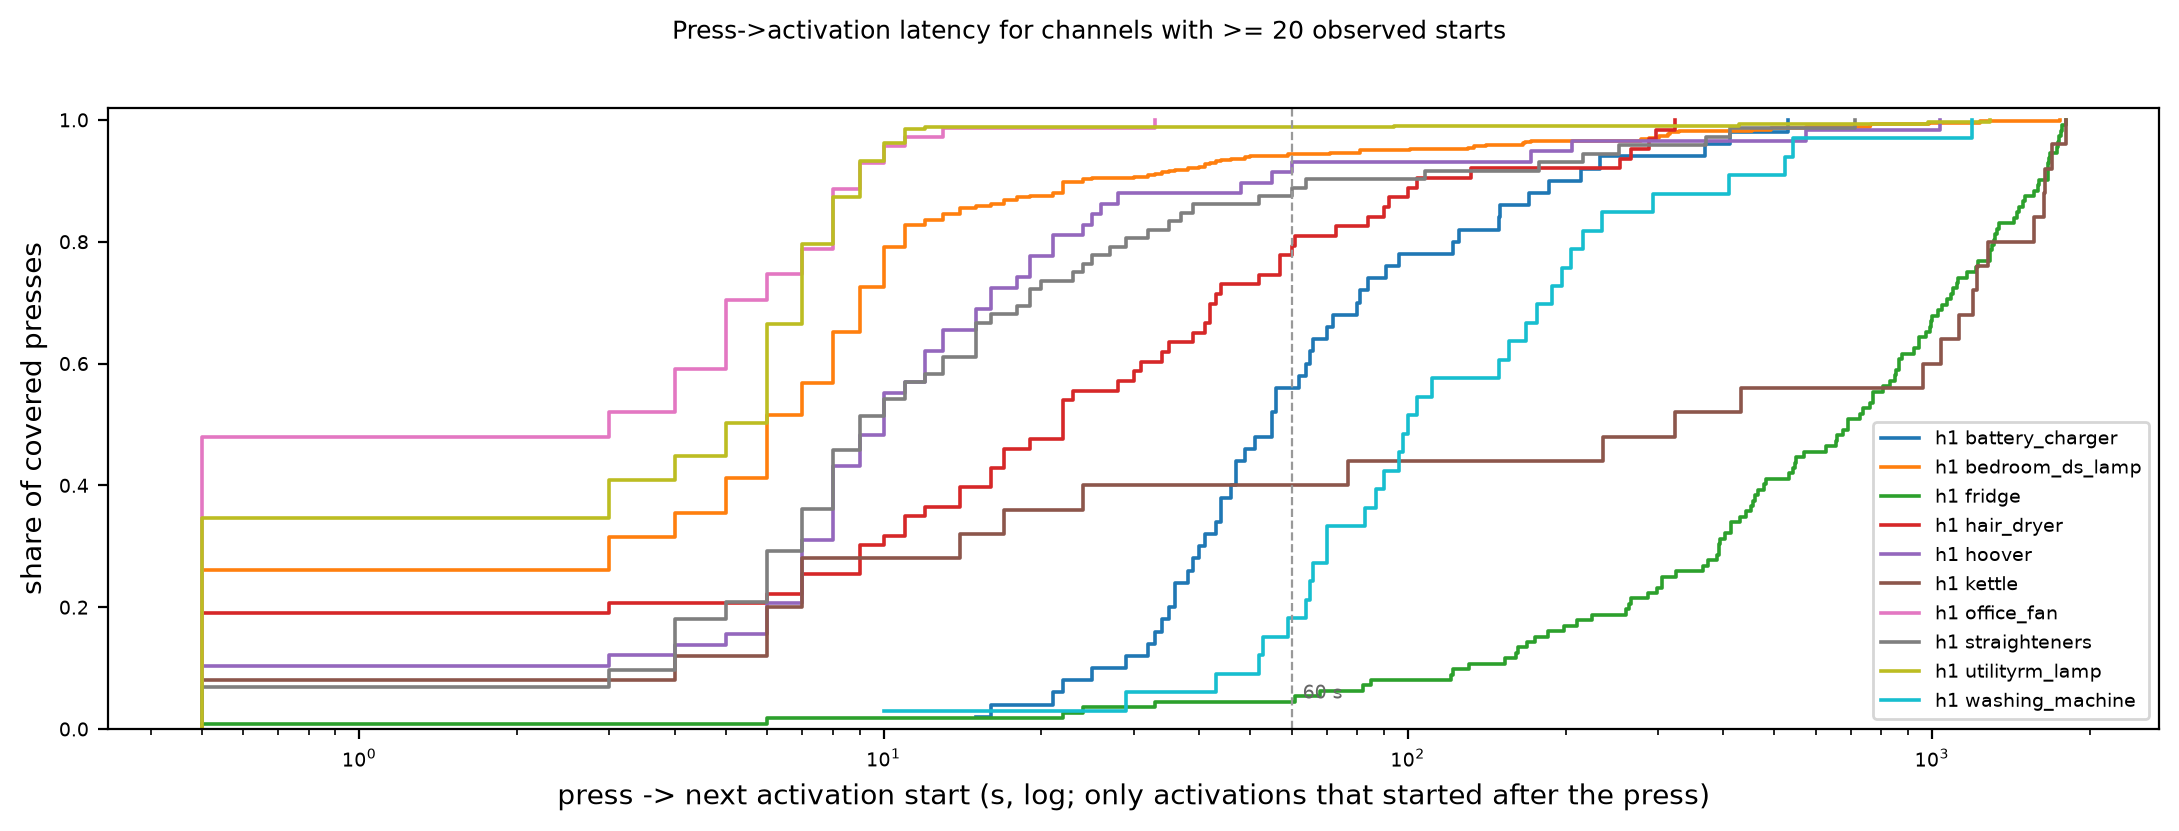

In [ ]:
# --- Figure: press->activation latency ECDFs ------------------------------
fig_latency, _ax = plt.subplots(figsize=(11, 4.2))
_na = press_lat[press_lat["mode"] == "new_activation"]
for (_house, _lab), _g in _na.groupby(["house", "label"]):
    _x = np.sort(_g["lat_s"].to_numpy())
    if len(_x) < 20:
        continue
    _y = np.arange(1, len(_x) + 1) / len(_x)
    _ax.step(np.maximum(_x, 0.5), _y, where="post", lw=1.3, label=f"{_house.replace('house_', 'h')} {_lab}")
_ax.axvline(60.0, color="#999999", lw=0.8, ls="--")
_ax.text(63.0, 0.05, "60 s", fontsize=7, color="#666666")
_ax.set_xscale("log")
_ax.set_xlabel("press -> next activation start (s, log; only activations that started after the press)")
_ax.set_ylabel("share of covered presses")
_ax.set_ylim(0, 1.02)
_ax.legend(fontsize=7, loc="lower right")
_ax.tick_params(labelsize=7)
fig_latency.suptitle("Press->activation latency for channels with >= 20 observed starts", fontsize=9)
fig_latency.tight_layout(rect=(0, 0, 1, 0.98))
fig_latency  # noqa: B018  (render figure as cell output)

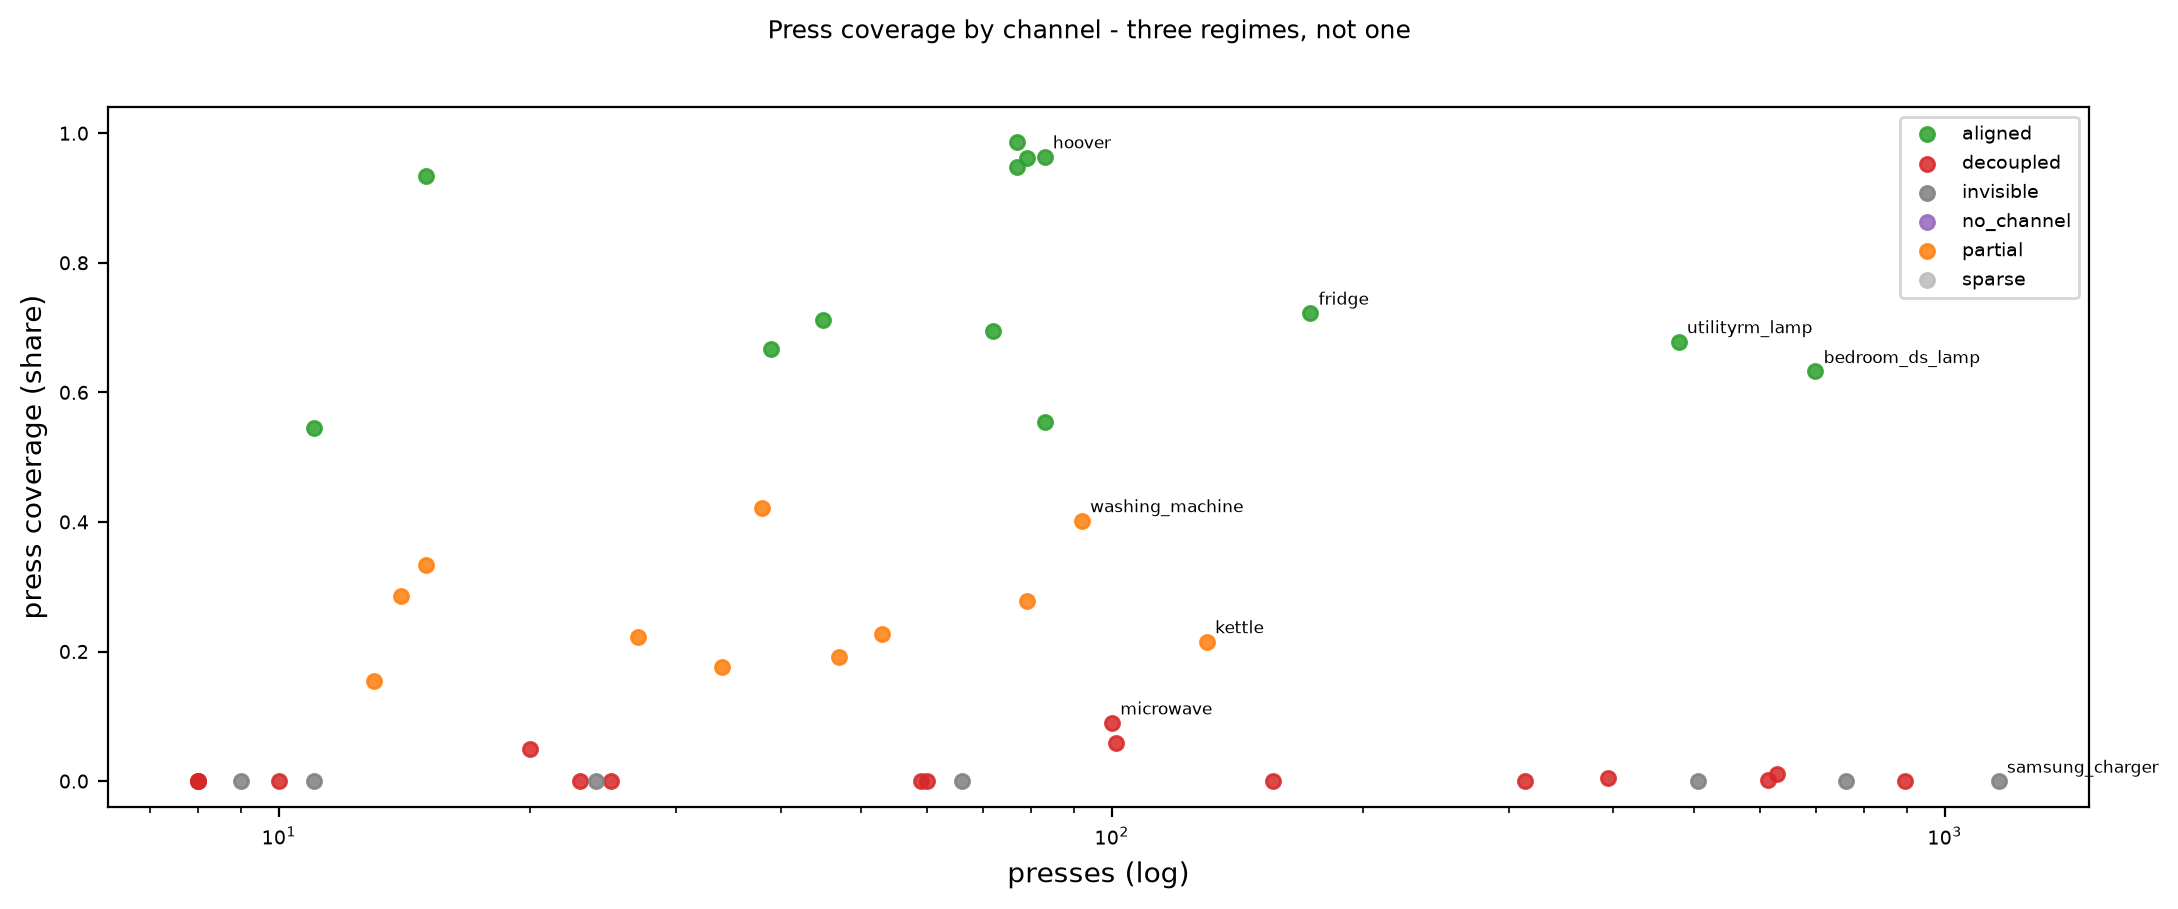

In [ ]:
# --- Figure: coverage vs press count per class ----------------------------
fig_cover, _ax = plt.subplots(figsize=(11, 4.6))
_cls_color = {
    "aligned": "#2ca02c",
    "partial": "#ff7f0e",
    "decoupled": "#d62728",
    "invisible": "#7f7f7f",
    "no_channel": "#9467bd",
}
for _cls, _g in align_df.groupby("class"):
    _ax.scatter(
        _g["presses"].to_numpy(),
        _g["cover"].to_numpy(),
        s=26,
        color=_cls_color.get(_cls, "#bbbbbb"),
        label=_cls,
        alpha=0.85,
    )
for _r in align_df.to_dict("records"):
    if _r["label"] in (
        "kettle",
        "hoover",
        "bedroom_ds_lamp",
        "utilityrm_lamp",
        "fridge",
        "microwave",
        "washing_machine",
        "samsung_charger",
    ):
        _ax.annotate(
            _r["label"],
            (_r["presses"], _r["cover"]),
            fontsize=6,
            xytext=(3, 3),
            textcoords="offset points",
        )
_ax.set_xscale("log")
_ax.set_xlabel("presses (log)")
_ax.set_ylabel("press coverage (share)")
_ax.set_ylim(-0.04, 1.04)
_ax.legend(fontsize=7)
_ax.tick_params(labelsize=7)
fig_cover.suptitle("Press coverage by channel - three regimes, not one", fontsize=9)
fig_cover.tight_layout(rect=(0, 0, 1, 0.98))
fig_cover  # noqa: B018  (render figure as cell output)

In [ ]:
# --- Overlay packs for exemplar channels (computation) --------------------
overlay_packs = {}
for _house, _ch, _lab in cfg["exemplars"]:
    _fig, _info = press_overlay(_house, _ch, _lab)
    _rec = align_df[(align_df["house"] == _house) & (align_df["label"] == _lab)]
    overlay_packs[f"{_house}|{_lab}"] = {
        "fig": _fig,
        "info": _info,
        "rec": _rec.iloc[0].to_dict() if len(_rec) else {},
    }

<marimo-accordion data-labels='["\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003eh1 - bedroom_ds_lamp (aligned, cover 0.63, lat p50 8.0 s)\u003c/span\u003e\u003c/span\u003e","\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003eh1 - utilityrm_lamp (aligned, cover 0.68, lat p50 7.0 s)\u003c/span\u003e\u003c/span\u003e","\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003eh1 - hoover (aligned, cover 0.96, lat p50 10.5 s)\u003c/span\u003e\u003c/span\u003e","\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003eh1 - kettle (partial, cover 0.22, lat p50 432.0 s)\u003c/span\u003e\u003c/span\u003e"]' data-multiple='false'> Best press-anchored day (most covered presses): submeter trace (orange) with press marks (blue), rule activations (green) + press markers (triangles) below. Aligned channels: each press sits on a draw edge. Decoupled channels: presses with no draw nearby. Best press-anchored day (most covered presses): submeter trace (orange) with press marks (blue), rule activations (green) + press markers (triangles) below. Aligned channels: each press sits on a draw edge. Decoupled channels: presses with no draw nearby. Best press-anchored day (most covered presses): submeter trace (orange) with press marks (blue), rule activations (green) + press markers (triangles) below. Aligned channels: each press sits on a draw edge. Decoupled channels: presses with no draw nearby. Best press-anchored day (most covered presses): submeter trace (orange) with press marks (blue), rule activations (green) + press markers (triangles) below. Aligned channels: each press sits on a draw edge. Decoupled channels: presses with no draw nearby.
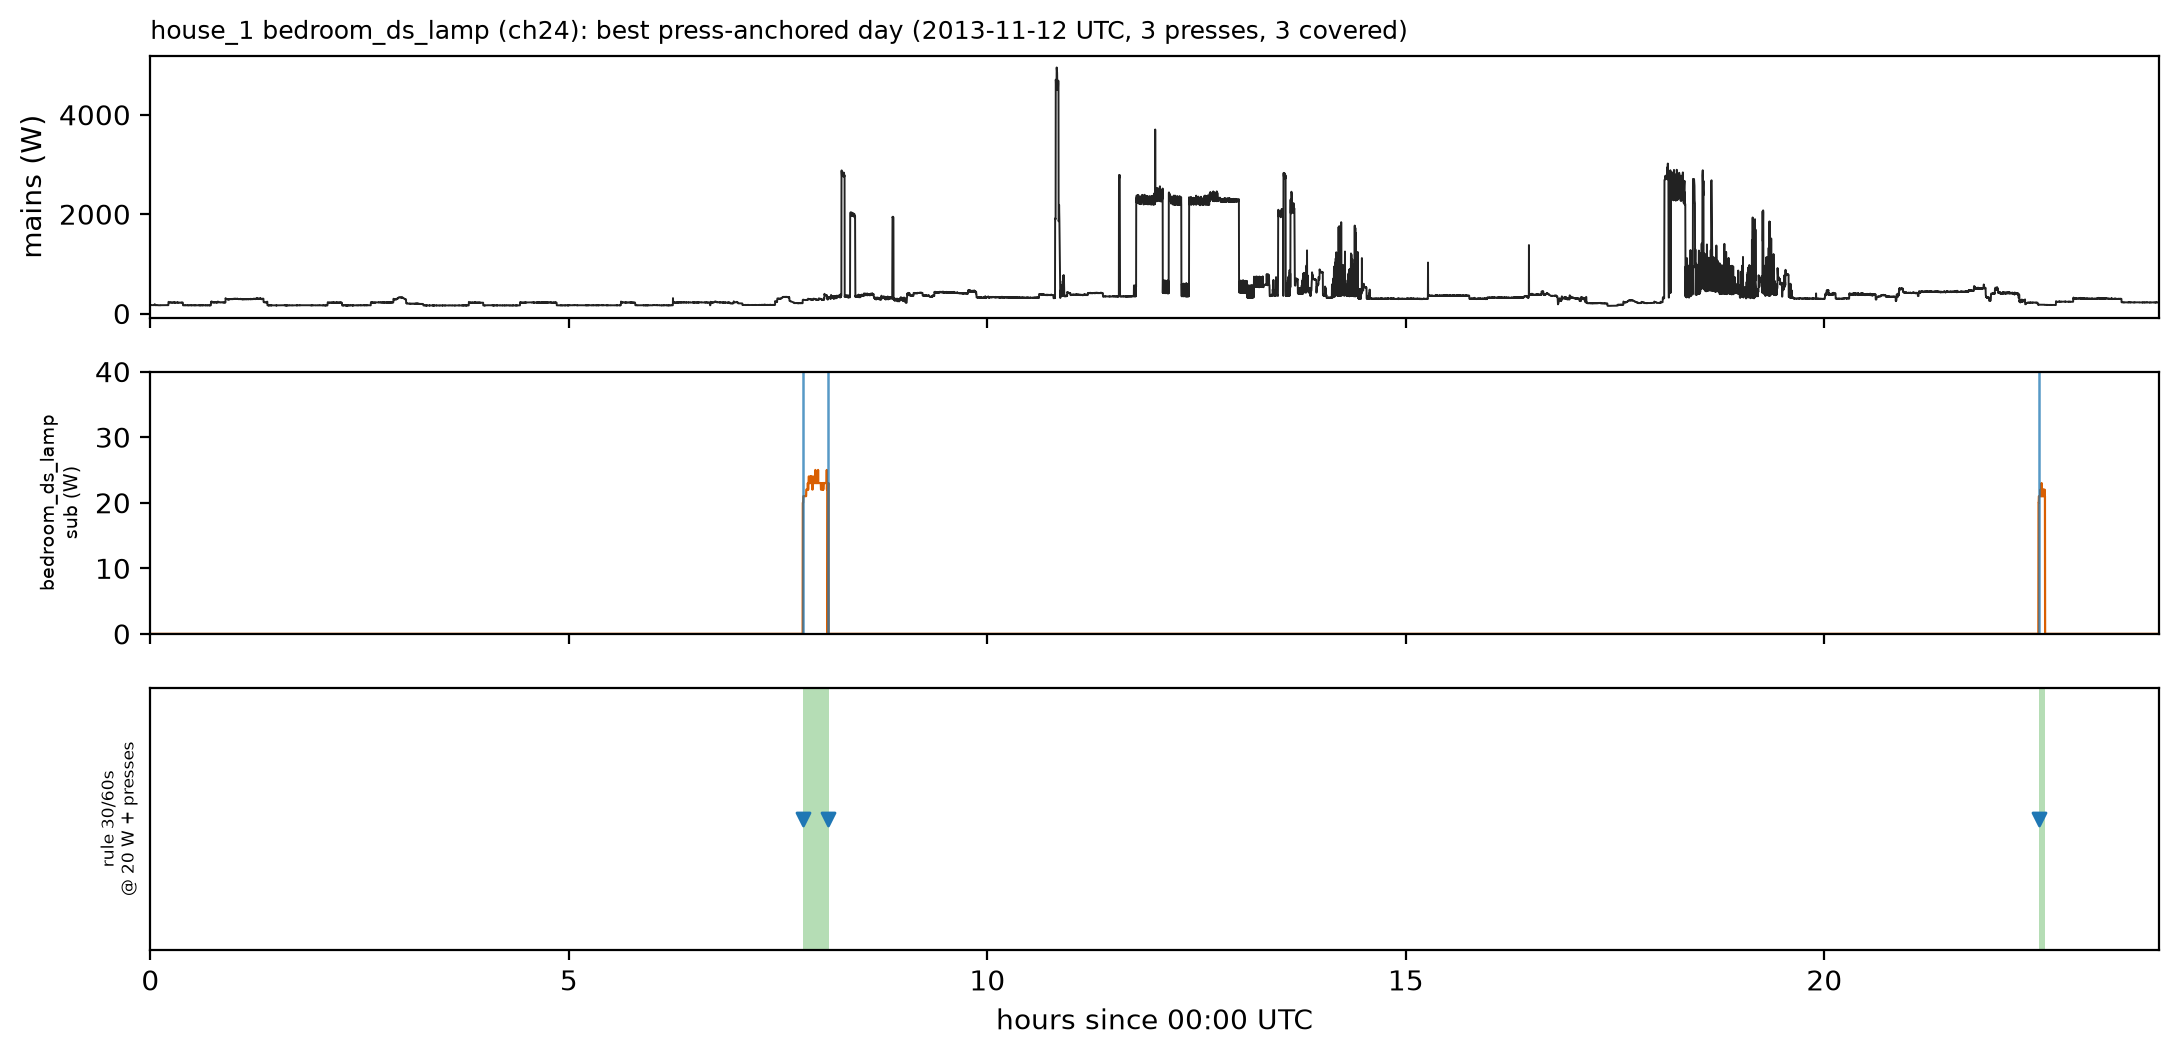
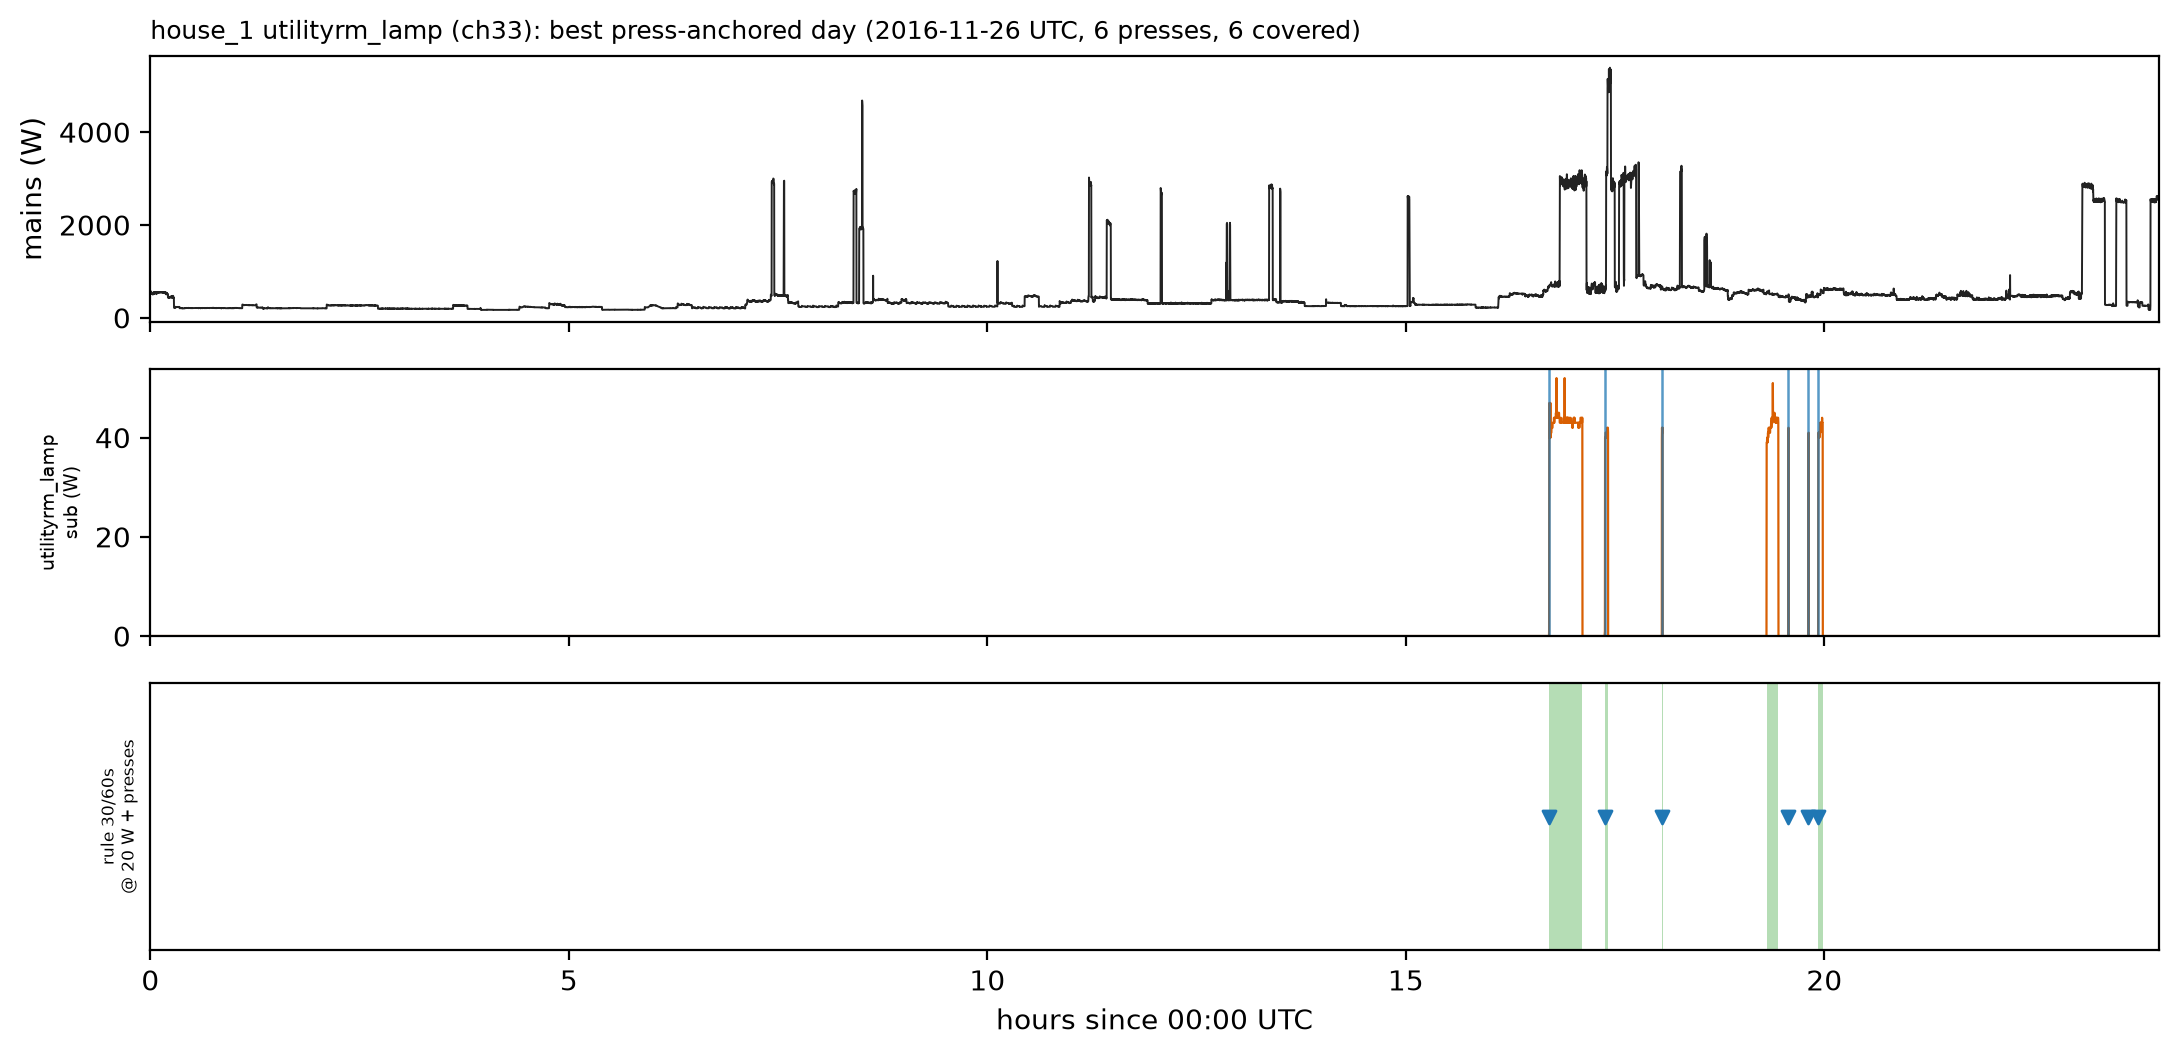
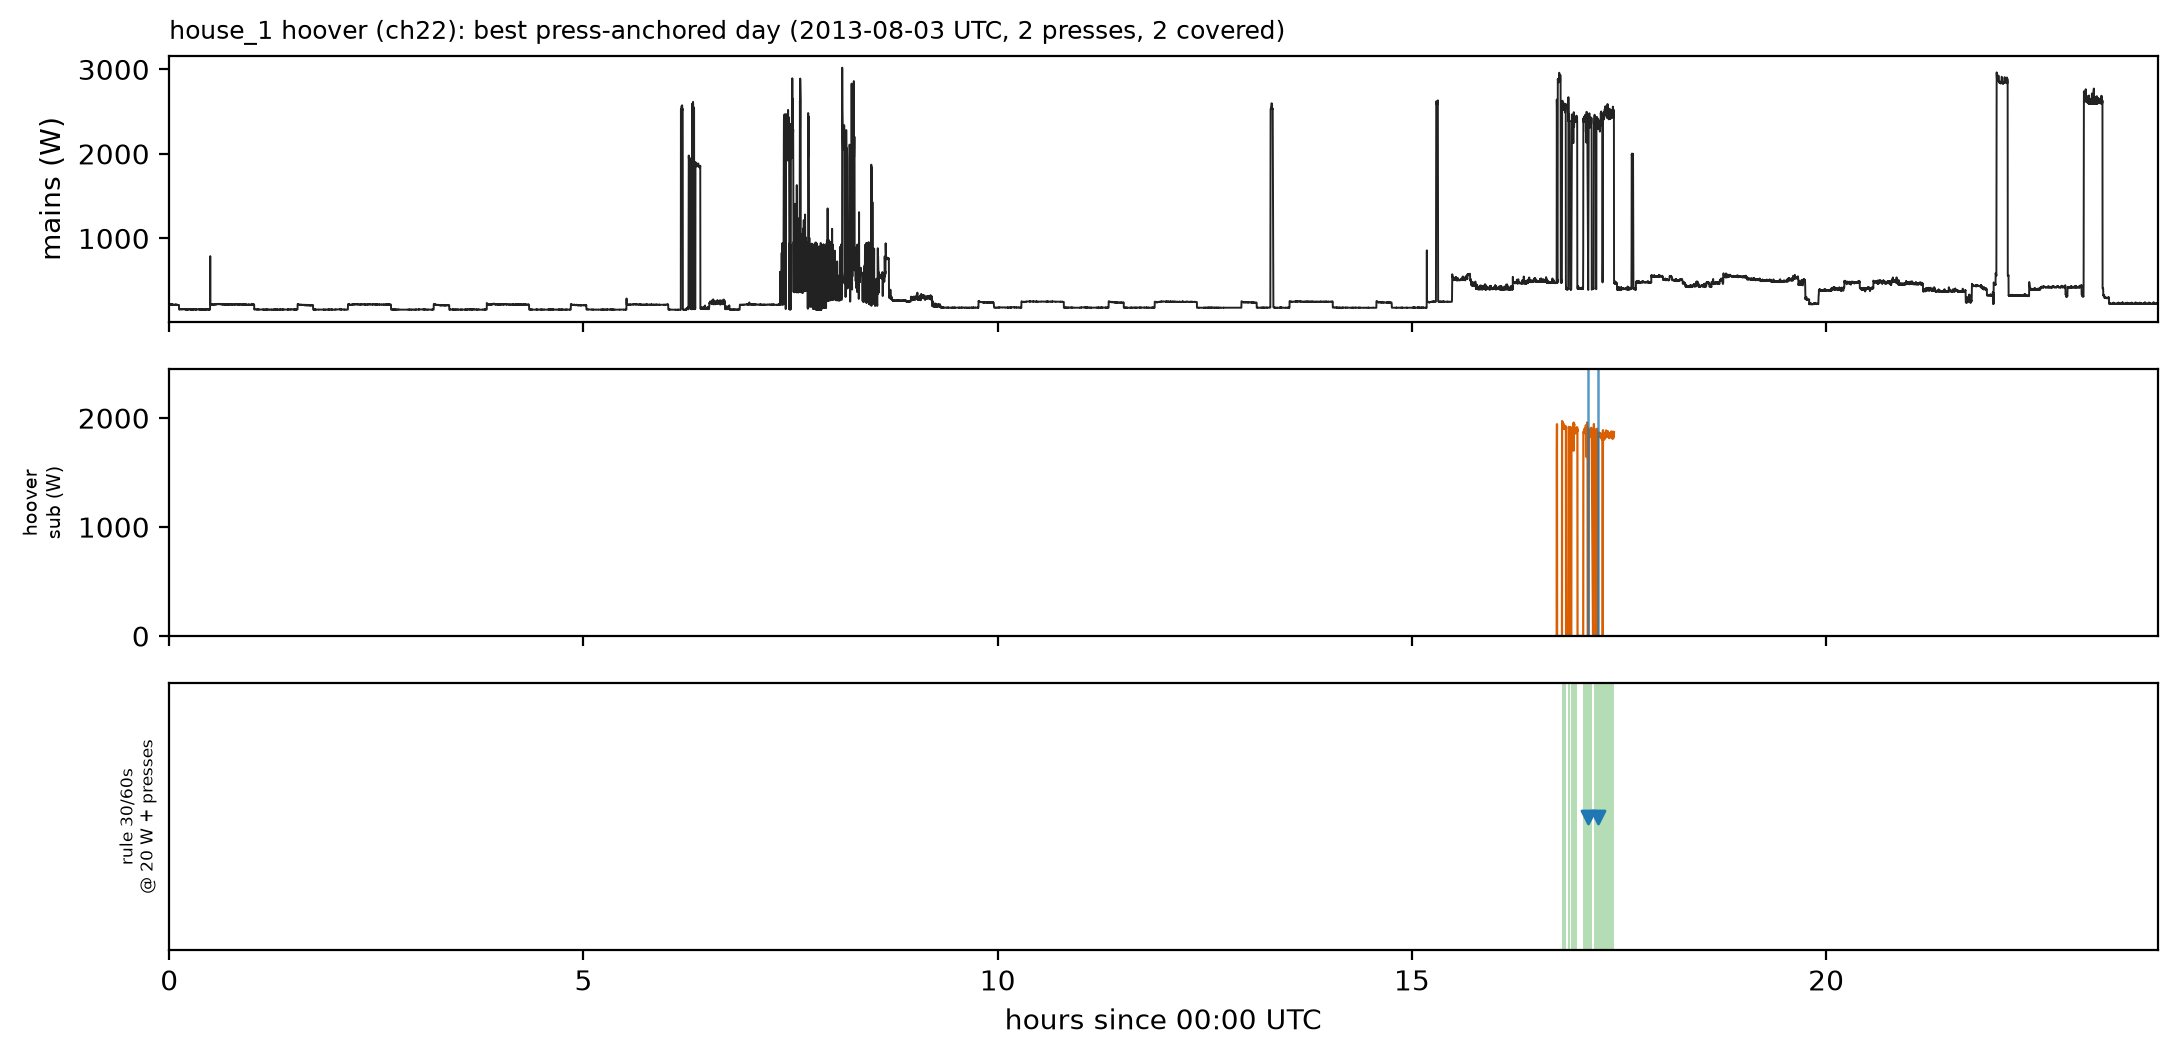
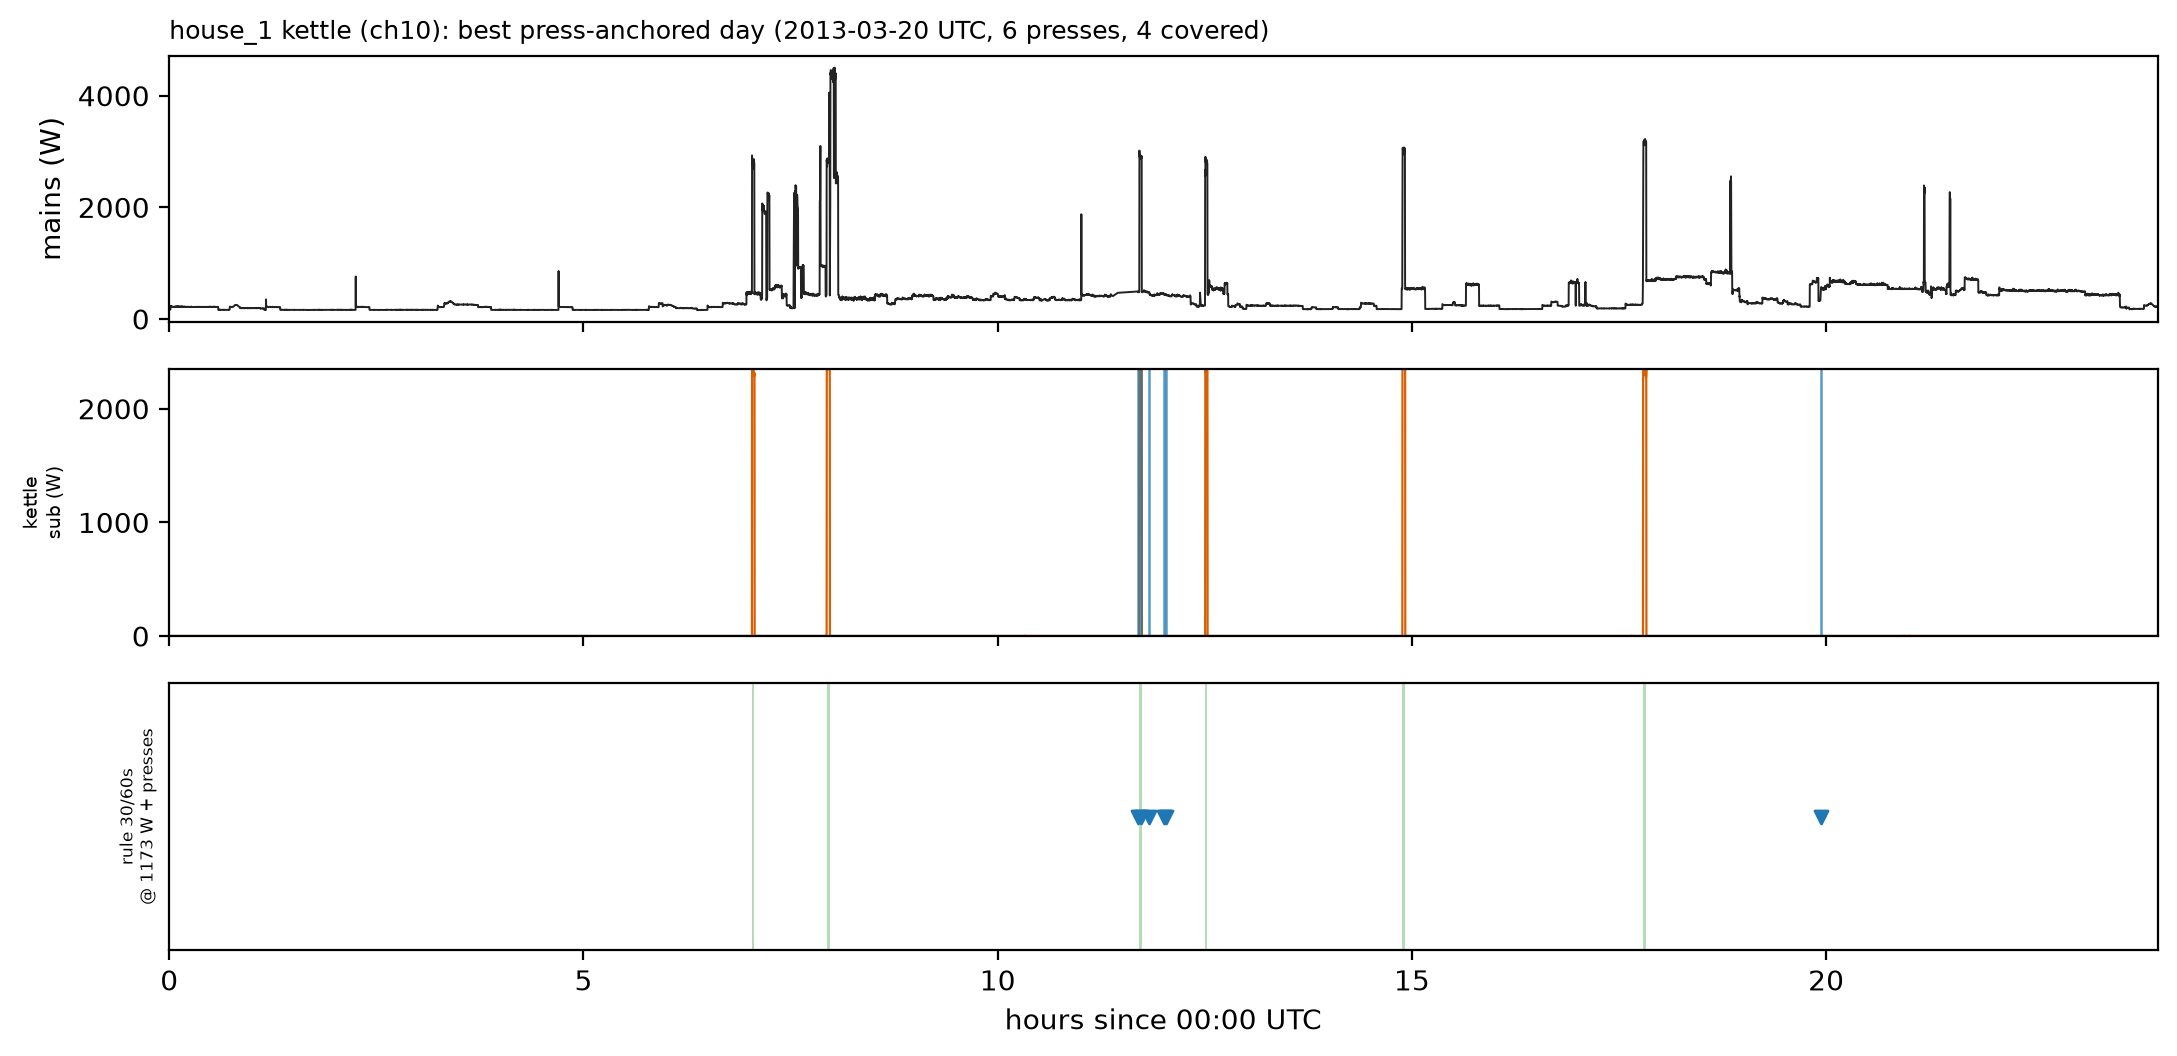

In [ ]:
# presentation: exemplar overlays in accordions
_items = {}
for _key, _pack in overlay_packs.items():
    _house, _lab = _key.split("|")
    _rec = _pack["rec"]
    _cls = _rec.get("class", "?")
    _title = (
        f"{_house.replace('house_', 'h')} - {_lab} ({_cls}, "
        f"cover {_rec.get('cover', float('nan')):.2f}, "
        f"lat p50 {_rec.get('lat_p50', float('nan')):.1f} s)"
    )
    _items[_title] = mo.vstack(
        [
            mo.md(
                "Best press-anchored day (most covered presses): submeter "
                "trace (orange) with press marks (blue), rule activations "
                "(green) + press markers (triangles) below. Aligned "
                "channels: each press sits on a draw edge. Decoupled "
                "channels: presses with no draw nearby."
            ),
            _pack["fig"],
        ]
    )
mo.accordion(_items)

## Findings

**Inventory (fig 1-2).** 71 button-press files, all UK-DALE: house_1 has
48 channels / 8,550 presses, house_2 11 / 42, house_5 12 / 121;
house_3/house_4 shipped none. Spans cover essentially the whole
deployment era (median ~4 years), so presses are time-aligned with the
submeter data. v0 is a clean binary press/release encoding (no other
values); presses exceed releases everywhere (h1: 8,550 vs 7,328) - held
buttons and log-boundary presses - so releases carry no trustworthy
semantics and are ignored downstream.

**Press-vs-activation alignment splits into three regimes (fig 3-4, table):**

1. **Aligned (cover >= 0.5) - the press protocol works.** Compliant
   personal-care and lamp loads: straighteners 0.99 (latency p50 10 s),
   hoover 0.96 (10.5 s), office_fan 0.96 (6 s), hair_dryer 0.95 (31 s),
   iron 0.93 (5 s), utilityrm_lamp 0.68 (7 s), bedroom_ds_lamp 0.63
   (8 s). For these, a press is a reliable cycle-start announcement.
2. **Partial (0.1-0.5).** toaster 0.42, washing_machine 0.40 (p50 100 s),
   kettle 0.22 (p50 432 s), gas_oven 0.19, breadmaker 0.18 - presses
   sometimes precede draws, but the modal press predicts nothing within
   minutes.
3. **Decoupled or invisible.** microwave 0.09, coffee_machine 0.06,
   dishwasher 0.05, and the always-on lamps/routers at 0.00. Seven
   channels have *no* activations above the 20 W threshold at all
   (samsung_charger with 1,160 presses at submeter p95 = 1 W,
   livingroom_s_lamp2, office_lamp2, baby_monitor_tx, office_lamp3,
   childs_table_lamp, h2 modem) - the presses are real, the draws are
   invisible. Four further h1 channels (kitchen_phone&stereo,
   gigE_&_USBhub, LED_printer, iPad_charger) have no gold channel.

**Coincidental coverage warning.** fridge (0.72) and laptop (0.67) look
aligned but are always-cycling loads: miss_frac = 1.00 and latency p50
692 s - coverage accumulated by chance, not protocol. Always read cover
together with miss_frac and latency.

**miss_frac mirrors the split.** Compliant lamps: 0.17-0.30 (most
activations are announced). Kitchen appliances: ~1.00 (draws are
un-announced). h2/h5 logs are too sparse (42/121 presses) to calibrate
anything.

**Implications for the button-press calibration simulation (H02).**
Press-derived priors are device-class dependent, and the measured
distributions above are the priors: for compliant classes sample
press-to-draw latency ~5-31 s (p50) with per-device coverage 0.93-0.99;
for partial classes coverage 0.2-0.4; for decoupled and invisible
channels simulate no press coverage at all. This is also why H02
replaces the retired upper-bound anchors: the press protocol is real
but only annotates a subset of devices - and now we know which, at what
latency, with what coverage.

**Store hygiene.** This notebook writes nothing: button-press logs are
annotation metadata (simulation priors), not cycle marks. The
manual-curation store remains the only source of hand-marked cycles.